# Fase 3 – Modelado experimental

## Predicción de concentraciones de PM2.5

**Proyecto:** Identificación de zonas críticas de contaminación atmosférica mediante técnicas GIS y aprendizaje automático utilizando concentraciones de PM2.5 registradas en la Ciudad de México durante el periodo 2024–2025.

**Responsable técnico:** Miranda Patricia Pérez Camelo

## Objetivo

Desarrollar y comparar modelos experimentales de regresión para estimar las concentraciones horarias de PM2.5 utilizando variables meteorológicas, temporales, geográficas y la estación de monitoreo.

Los modelos se entrenarán con los registros de 2024 y se evaluarán con los registros de 2025, evitando mezclar temporalmente los datos de entrenamiento y prueba.

## Modelos evaluados

1. Dummy Regressor como referencia básica.
2. Regresión lineal como modelo base.
3. Random Forest Regressor como modelo no lineal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
CARPETA_PROYECTO = Path("..")
CARPETA_RESULTADOS = CARPETA_PROYECTO / "resultados"

CARPETA_FIGURAS = CARPETA_RESULTADOS / "figuras_modelado"
CARPETA_MODELOS = CARPETA_RESULTADOS / "modelos"
CARPETA_TABLAS = CARPETA_RESULTADOS / "tablas"

CARPETA_FIGURAS.mkdir(parents=True, exist_ok=True)
CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)
CARPETA_TABLAS.mkdir(parents=True, exist_ok=True)

RUTA_DATASET = (
    CARPETA_RESULTADOS
    / "dataset_modelo_completo_2024_2025.csv"
)

print("Ruta del dataset:")
print(RUTA_DATASET.resolve())

print("\n¿Existe el archivo?")
print(RUTA_DATASET.exists())

Ruta del dataset:
C:\Users\pmiri\OneDrive\Desktop\ProyAmbiental\resultados\dataset_modelo_completo_2024_2025.csv

¿Existe el archivo?
True


## 1. Carga y validación de los datos para modelado

Se utilizará el dataset que contiene registros con PM2.5, temperatura, humedad relativa, velocidad y dirección del viento, así como información temporal y geográfica.

Este archivo fue generado durante la etapa de integración de datos.

In [3]:
datos = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["DATETIME", "FECHA"],
    low_memory=False
)

print("Dataset cargado correctamente")
print("Dimensiones:", datos.shape)

datos.head()

Dataset cargado correctamente
Dimensiones: (108060, 19)


,DATETIME,FECHA,HORA,ANIO,MES,DIA,DIA_SEMANA,HORA_DIA,ESTACION,nom_estac,PM25,TMP,RH,WSP,WDR,longitud,latitud,alt,id_station
0,2024-01-01,2024-01-01,1,2024,1,1,0,0,AJM,Ajusco Medio,33.0,6.0,57.0,3.5,320.0,-99.207744,19.272161,2548.0,484090120609
1,2024-01-01,2024-01-01,1,2024,1,1,0,0,BJU,Benito Juárez,42.0,12.0,56.0,0.8,173.0,-99.159596,19.370464,2249.0,484090140201
2,2024-01-01,2024-01-01,1,2024,1,1,0,0,MER,Merced,52.0,14.0,56.0,0.7,304.0,-99.119594,19.424610,2245.0,484090170127
3,2024-01-01,2024-01-01,1,2024,1,1,0,0,SAC,Santiago Acahualtepec,107.0,9.0,61.0,0.7,148.0,-99.009381,19.345610,2293.0,484800090073
4,2024-01-01,2024-01-01,1,2024,1,1,0,0,SAG,San Agustín,55.0,13.0,67.0,0.5,60.0,-99.030324,19.532968,2241.0,484150330327


In [4]:
print(datos.columns.tolist())

['DATETIME', 'FECHA', 'HORA', 'ANIO', 'MES', 'DIA', 'DIA_SEMANA', 'HORA_DIA', 'ESTACION', 'nom_estac', 'PM25', 'TMP', 'RH', 'WSP', 'WDR', 'longitud', 'latitud', 'alt', 'id_station']


In [5]:
columnas_modelado = [
    "PM25",
    "TMP",
    "RH",
    "WSP",
    "WDR",
    "longitud",
    "latitud",
    "alt"
]

datos[columnas_modelado].isna().sum()

PM25        0
TMP         0
RH          0
WSP         0
WDR         0
longitud    0
latitud     0
alt         0
dtype: int64

In [6]:
duplicados = datos.duplicated(
    subset=["DATETIME", "ESTACION"]
).sum()

print("Duplicados:", duplicados)

Duplicados: 0


In [7]:
datos_modelo = datos.copy()

print("Copia de trabajo creada")

Copia de trabajo creada


In [8]:
cantidad_rh_negativa = (
    datos_modelo["RH"] < 0
).sum()

print(
    "Registros con humedad negativa:",
    cantidad_rh_negativa
)

Registros con humedad negativa: 3


In [9]:
datos_modelo.loc[
    datos_modelo["RH"] < 0,
    "RH"
] = np.nan

### Control de calidad

Los valores negativos de humedad relativa se consideraron físicamente inválidos y se transformaron en valores faltantes dentro de la copia utilizada para modelado. Posteriormente, el pipeline se encargará de imputarlos mediante la mediana del conjunto de entrenamiento.

## 2. Ingeniería de variables

Las variables temporales y la dirección del viento son cíclicas.

Por ejemplo:

- Después de las 23:00 horas vuelve a comenzar la hora 00:00.
- Después de diciembre vuelve enero.
- Una dirección de viento de 359° es muy cercana a 1°.

Por esta razón, estas variables se transformarán mediante componentes seno y coseno.

In [11]:
direccion_radianes = np.deg2rad(
    datos_modelo["WDR"]
)

datos_modelo["WDR_SIN"] = np.sin(
    direccion_radianes
)

datos_modelo["WDR_COS"] = np.cos(
    direccion_radianes
)

In [12]:
datos_modelo["HORA_SIN"] = np.sin(
    2 * np.pi
    * datos_modelo["HORA_DIA"]
    / 24
)

datos_modelo["HORA_COS"] = np.cos(
    2 * np.pi
    * datos_modelo["HORA_DIA"]
    / 24
)

In [13]:
datos_modelo["MES_SIN"] = np.sin(
    2 * np.pi
    * datos_modelo["MES"]
    / 12
)

datos_modelo["MES_COS"] = np.cos(
    2 * np.pi
    * datos_modelo["MES"]
    / 12
)

In [14]:
datos_modelo["DIA_SEMANA_SIN"] = np.sin(
    2 * np.pi
    * datos_modelo["DIA_SEMANA"]
    / 7
)

datos_modelo["DIA_SEMANA_COS"] = np.cos(
    2 * np.pi
    * datos_modelo["DIA_SEMANA"]
    / 7
)

In [15]:
datos_modelo[
    [
        "WDR",
        "WDR_SIN",
        "WDR_COS",
        "HORA_DIA",
        "HORA_SIN",
        "HORA_COS",
        "MES",
        "MES_SIN",
        "MES_COS"
    ]
].head()

,WDR,WDR_SIN,WDR_COS,HORA_DIA,HORA_SIN,HORA_COS,MES,MES_SIN,MES_COS
0,320.0,-0.642788,0.766044,0,0.0,1.0,1,0.5,0.866025
1,173.0,0.121869,-0.992546,0,0.0,1.0,1,0.5,0.866025
2,304.0,-0.829038,0.559193,0,0.0,1.0,1,0.5,0.866025
3,148.0,0.529919,-0.848048,0,0.0,1.0,1,0.5,0.866025
4,60.0,0.866025,0.500000,0,0.0,1.0,1,0.5,0.866025


## 3. Selección de variables

La variable objetivo será PM2.5.

Como variables predictoras se utilizarán:

- Temperatura.
- Humedad relativa.
- Velocidad del viento.
- Dirección del viento transformada.
- Hora del día transformada.
- Mes transformado.
- Día de la semana transformado.
- Longitud.
- Latitud.
- Altitud.
- Estación de monitoreo.

In [16]:
variables_numericas = [
    "TMP",
    "RH",
    "WSP",
    "WDR_SIN",
    "WDR_COS",
    "HORA_SIN",
    "HORA_COS",
    "MES_SIN",
    "MES_COS",
    "DIA_SEMANA_SIN",
    "DIA_SEMANA_COS",
    "longitud",
    "latitud",
    "alt"
]

variables_categoricas = [
    "ESTACION"
]

variable_objetivo = "PM25"

In [17]:
X = datos_modelo[
    variables_numericas
    + variables_categoricas
].copy()

y = datos_modelo[
    variable_objetivo
].copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (108060, 15)
Dimensiones de y: (108060,)


## 4. División temporal del conjunto de datos

Se utilizarán los registros de 2024 para entrenar los modelos y los registros de 2025 para evaluarlos.

Esta división evita que el modelo utilice información futura durante el entrenamiento y proporciona una evaluación más realista de su capacidad de generalización.

In [18]:
mascara_entrenamiento = (
    datos_modelo["ANIO"] == 2024
)

mascara_prueba = (
    datos_modelo["ANIO"] == 2025
)

In [19]:
X_train = X.loc[
    mascara_entrenamiento
].copy()

y_train = y.loc[
    mascara_entrenamiento
].copy()

X_test = X.loc[
    mascara_prueba
].copy()

y_test = y.loc[
    mascara_prueba
].copy()

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print(
    "Promedio PM2.5 entrenamiento:",
    round(y_train.mean(), 2)
)

print(
    "Promedio PM2.5 prueba:",
    round(y_test.mean(), 2)
)

Entrenamiento: (47922, 15)
Prueba: (60138, 15)
Promedio PM2.5 entrenamiento: 21.02
Promedio PM2.5 prueba: 19.81


In [20]:
estaciones_train = set(
    X_train["ESTACION"].unique()
)

estaciones_test = set(
    X_test["ESTACION"].unique()
)

print(
    "Estaciones en entrenamiento:",
    len(estaciones_train)
)

print(
    "Estaciones en prueba:",
    len(estaciones_test)
)

print("\nEstaciones solo presentes en prueba:")

print(
    sorted(
        estaciones_test
        - estaciones_train
    )
)

Estaciones en entrenamiento: 13
Estaciones en prueba: 14

Estaciones solo presentes en prueba:
['UIZ']


In [21]:
handle_unknown="ignore"

## 5. Métricas de evaluación

Se utilizarán las siguientes métricas:

- **MAE:** error absoluto promedio. Indica cuántas unidades se desvía el modelo en promedio.
- **RMSE:** penaliza más los errores grandes.
- **R²:** indica qué proporción de la variabilidad de PM2.5 logra explicar el modelo.

Un MAE y RMSE menores representan un mejor desempeño. Un R² mayor representa una mayor capacidad explicativa.

In [22]:
def evaluar_modelo(
    nombre_modelo,
    y_real,
    y_predicho
):
    mae = mean_absolute_error(
        y_real,
        y_predicho
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_real,
            y_predicho
        )
    )

    r2 = r2_score(
        y_real,
        y_predicho
    )

    resultado = {
        "modelo": nombre_modelo,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    print(f"Modelo: {nombre_modelo}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")

    return resultado

## 6. Modelo de referencia: Dummy Regressor

El Dummy Regressor se utilizará como referencia mínima. Un modelo útil deberá obtener mejores resultados que esta estrategia básica.

In [23]:
modelo_dummy = DummyRegressor(
    strategy="mean"
)

modelo_dummy.fit(
    X_train,
    y_train
)

pred_dummy = modelo_dummy.predict(
    X_test
)

In [24]:
resultados_modelos = []

resultado_dummy = evaluar_modelo(
    "Dummy Regressor",
    y_test,
    pred_dummy
)

resultados_modelos.append(
    resultado_dummy
)

Modelo: Dummy Regressor
MAE: 9.0678
RMSE: 11.7033
R²: -0.0108


In [25]:
pipeline_numerico_lineal = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "escalado",
            StandardScaler()
        )
    ]
)

In [26]:
pipeline_categorico = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [27]:
preprocesador_lineal = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico_lineal,
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

## 7. Regresión lineal

La regresión lineal se utilizará como modelo base para evaluar si las variables presentan una relación lineal suficiente para explicar las concentraciones de PM2.5.

In [28]:
modelo_lineal = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_lineal
        ),
        (
            "modelo",
            LinearRegression()
        )
    ]
)

In [29]:
modelo_lineal.fit(
    X_train,
    y_train
)

print("Regresión lineal entrenada")

Regresión lineal entrenada


In [30]:
pred_lineal = modelo_lineal.predict(
    X_test
)

In [31]:
resultado_lineal = evaluar_modelo(
    "Regresión lineal",
    y_test,
    pred_lineal
)

resultados_modelos.append(
    resultado_lineal
)

Modelo: Regresión lineal
MAE: 8.0918
RMSE: 10.7196
R²: 0.1520


In [32]:
pipeline_numerico_arbol = Pipeline(
    steps=[
        (
            "imputacion",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

In [33]:
preprocesador_arbol = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico_arbol,
            variables_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variables_categoricas
        )
    ]
)

In [34]:
print(
    "Registros originales de entrenamiento:",
    len(X_train)
)

Registros originales de entrenamiento: 47922


In [35]:
MAXIMO_ENTRENAMIENTO = 120000

if len(X_train) > MAXIMO_ENTRENAMIENTO:

    indices_muestra = X_train.sample(
        n=MAXIMO_ENTRENAMIENTO,
        random_state=42
    ).index

    X_train_rf = X_train.loc[
        indices_muestra
    ].copy()

    y_train_rf = y_train.loc[
        indices_muestra
    ].copy()

else:

    X_train_rf = X_train.copy()
    y_train_rf = y_train.copy()

print(
    "Registros utilizados por Random Forest:",
    len(X_train_rf)
)

Registros utilizados por Random Forest: 47922


## 8. Random Forest Regressor

Random Forest combina múltiples árboles de decisión y permite representar relaciones no lineales e interacciones entre variables.

Se utilizará una configuración moderada para evitar un consumo excesivo de memoria durante el primer experimento.

In [36]:
random_forest = RandomForestRegressor(
    n_estimators=60,
    max_depth=18,
    min_samples_leaf=5,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

In [37]:
modelo_rf = Pipeline(
    steps=[
        (
            "preprocesamiento",
            preprocesador_arbol
        ),
        (
            "modelo",
            random_forest
        )
    ]
)

In [38]:
modelo_rf.fit(
    X_train_rf,
    y_train_rf
)

print("Random Forest entrenado")

Random Forest entrenado


In [39]:
pred_rf = modelo_rf.predict(
    X_test
)

In [40]:
resultado_rf = evaluar_modelo(
    "Random Forest",
    y_test,
    pred_rf
)

resultados_modelos.append(
    resultado_rf
)

Modelo: Random Forest
MAE: 7.3059
RMSE: 9.8556
R²: 0.2832


## 9. Comparación de modelos

Se compararán las métricas de los tres modelos para determinar cuál presenta mayor capacidad predictiva sobre los datos de 2025.

In [41]:
tabla_resultados = pd.DataFrame(
    resultados_modelos
)

tabla_resultados = tabla_resultados.sort_values(
    by="RMSE",
    ascending=True
).reset_index(drop=True)

tabla_resultados

,modelo,MAE,RMSE,R2
0,Random Forest,7.305852,9.855644,0.283173
1,Regresión lineal,8.091769,10.719582,0.151992
2,Dummy Regressor,9.067805,11.703331,-0.010795


In [42]:
ruta_metricas = (
    CARPETA_TABLAS
    / "metricas_modelos_regresion.csv"
)

tabla_resultados.to_csv(
    ruta_metricas,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Métricas guardadas:",
    ruta_metricas.exists()
)

Métricas guardadas: True


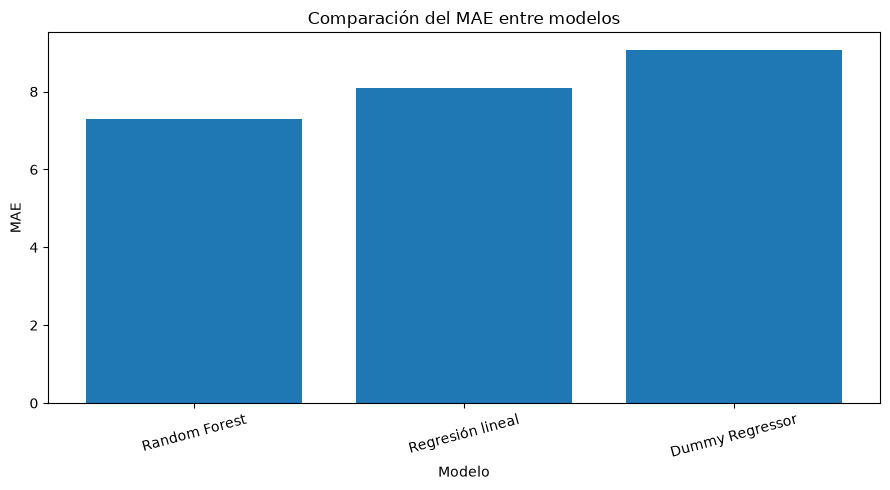

In [43]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabla_resultados["modelo"],
    tabla_resultados["MAE"]
)

plt.title("Comparación del MAE entre modelos")
plt.xlabel("Modelo")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_mae_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

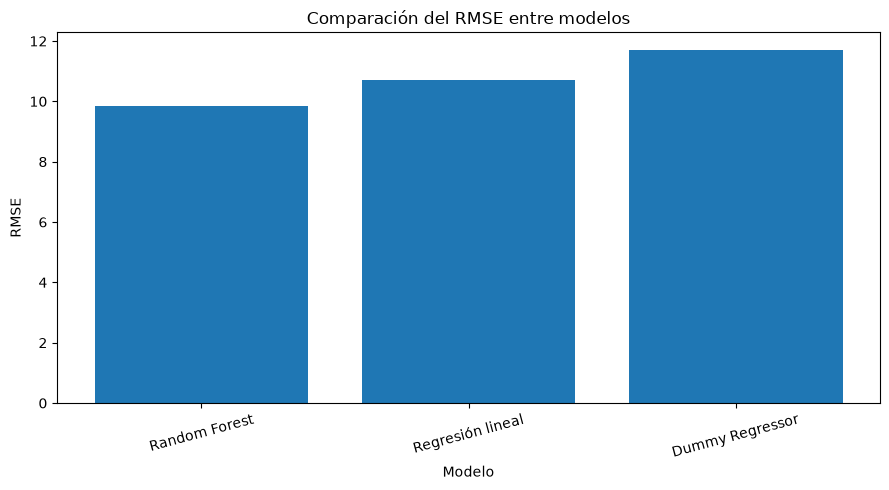

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabla_resultados["modelo"],
    tabla_resultados["RMSE"]
)

plt.title("Comparación del RMSE entre modelos")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_rmse_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

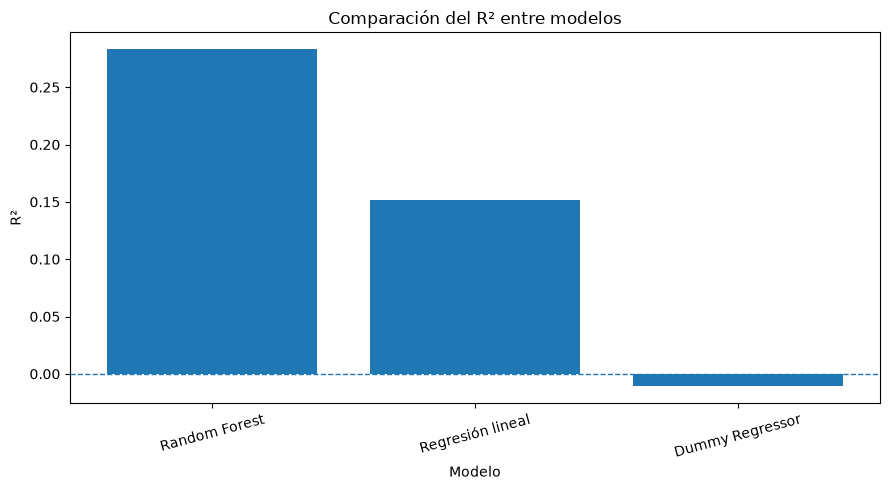

In [45]:
plt.figure(figsize=(9, 5))

plt.bar(
    tabla_resultados["modelo"],
    tabla_resultados["R2"]
)

plt.title("Comparación del R² entre modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "comparacion_r2_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
cantidad_grafica = min(
    5000,
    len(y_test)
)

indices_grafica = y_test.sample(
    n=cantidad_grafica,
    random_state=42
).index

In [47]:
pred_rf_serie = pd.Series(
    pred_rf,
    index=y_test.index,
    name="PM25_PREDICHO_RF"
)

pred_lineal_serie = pd.Series(
    pred_lineal,
    index=y_test.index,
    name="PM25_PREDICHO_LINEAL"
)

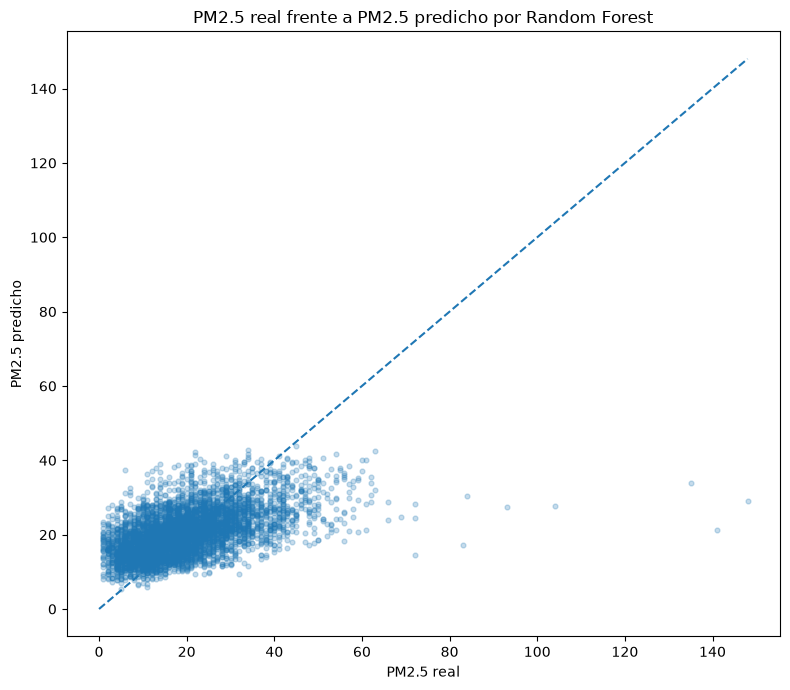

In [48]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test.loc[indices_grafica],
    pred_rf_serie.loc[indices_grafica],
    alpha=0.25,
    s=12
)

limite_maximo = max(
    y_test.loc[indices_grafica].max(),
    pred_rf_serie.loc[indices_grafica].max()
)

plt.plot(
    [0, limite_maximo],
    [0, limite_maximo],
    linestyle="--"
)

plt.title(
    "PM2.5 real frente a PM2.5 predicho por Random Forest"
)
plt.xlabel("PM2.5 real")
plt.ylabel("PM2.5 predicho")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "real_vs_predicho_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
resultados_prueba = datos_modelo.loc[
    mascara_prueba,
    [
        "DATETIME",
        "ESTACION",
        "nom_estac",
        "PM25",
        "TMP",
        "RH",
        "WSP",
        "WDR",
        "longitud",
        "latitud"
    ]
].copy()

resultados_prueba[
    "PRED_DUMMY"
] = pred_dummy

resultados_prueba[
    "PRED_LINEAL"
] = pred_lineal

resultados_prueba[
    "PRED_RF"
] = pred_rf

resultados_prueba[
    "ERROR_RF"
] = (
    resultados_prueba["PM25"]
    - resultados_prueba["PRED_RF"]
)

resultados_prueba[
    "ERROR_ABS_RF"
] = resultados_prueba[
    "ERROR_RF"
].abs()

resultados_prueba.head()

,DATETIME,ESTACION,nom_estac,PM25,TMP,RH,WSP,WDR,longitud,latitud,PRED_DUMMY,PRED_LINEAL,PRED_RF,ERROR_RF,ERROR_ABS_RF
47922,2025-01-01,AJM,Ajusco Medio,13.0,9.6,34.0,4.16,221.0,-99.207744,19.272161,21.019135,10.267938,10.664979,2.335021,2.335021
47923,2025-01-01,MON,Montecillo,107.0,10.1,42.0,1.12,128.0,-98.902853,19.460415,21.019135,22.623632,26.731171,80.268829,80.268829
47924,2025-01-01,NEZ,Nezahualcóyotl,105.0,14.1,26.0,1.48,323.0,-99.028212,19.393734,21.019135,19.982331,20.755279,84.244721,84.244721
47925,2025-01-01,PED,Pedregal,33.0,11.8,34.0,1.92,215.0,-99.204136,19.325146,21.019135,14.805880,11.649020,21.350980,21.350980
47926,2025-01-01,UAX,UAM Xochimilco,81.0,13.3,41.0,1.07,231.0,-99.103629,19.304441,21.019135,23.198537,21.536635,59.463365,59.463365


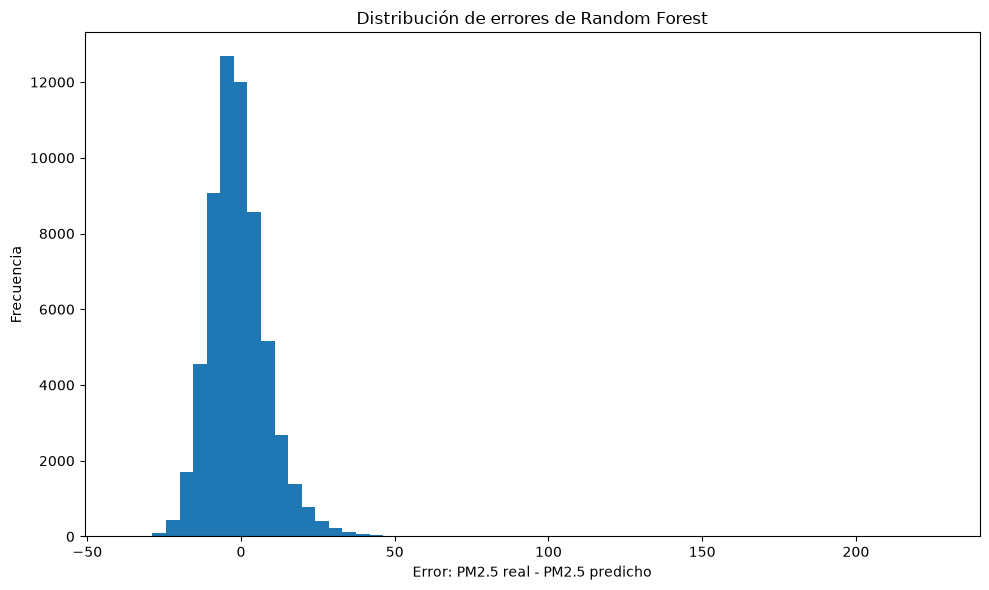

In [50]:
plt.figure(figsize=(10, 6))

plt.hist(
    resultados_prueba["ERROR_RF"],
    bins=60
)

plt.title(
    "Distribución de errores de Random Forest"
)
plt.xlabel(
    "Error: PM2.5 real - PM2.5 predicho"
)
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "distribucion_errores_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [51]:
error_por_estacion = (
    resultados_prueba
    .groupby(
        [
            "ESTACION",
            "nom_estac"
        ],
        as_index=False
    )
    .agg(
        registros=("PM25", "count"),
        MAE_RF=("ERROR_ABS_RF", "mean"),
        error_promedio=("ERROR_RF", "mean")
    )
    .sort_values(
        by="MAE_RF",
        ascending=False
    )
)

error_por_estacion.head(10)

,ESTACION,nom_estac,registros,MAE_RF,error_promedio
6,MON,Montecillo,166,13.954941,3.639108
8,NEZ,Nezahualcóyotl,5641,8.000139,0.189226
12,UAX,UAM Xochimilco,7824,7.977734,-3.467391
3,GAM,Gustavo A. Madero,6199,7.784785,0.557686
10,SAC,Santiago Acahualtepec,1792,7.519957,-1.279212
5,MER,Merced,7665,7.461984,-1.420749
13,UIZ,UAM Iztapalapa,2524,7.348669,-2.582910
1,BJU,Benito Juárez,4920,7.304204,-0.818109
9,PED,Pedregal,7859,6.940653,-0.529830
11,SAG,San Agustín,1482,6.830963,-0.590057


In [52]:
preprocesador_entrenado = (
    modelo_rf.named_steps[
        "preprocesamiento"
    ]
)

nombres_variables = (
    preprocesador_entrenado
    .get_feature_names_out()
)

importancias = (
    modelo_rf.named_steps[
        "modelo"
    ]
    .feature_importances_
)

In [53]:
tabla_importancias = pd.DataFrame({
    "variable": nombres_variables,
    "importancia": importancias
}).sort_values(
    by="importancia",
    ascending=False
)

tabla_importancias.head(20)

,variable,importancia
0,numericas__TMP,0.108421
1,numericas__RH,0.104541
7,numericas__MES_SIN,0.094422
2,numericas__WSP,0.092181
6,numericas__HORA_COS,0.087313
4,numericas__WDR_COS,0.073027
3,numericas__WDR_SIN,0.066968
5,numericas__HORA_SIN,0.065076
8,numericas__MES_COS,0.064541
13,numericas__alt,0.052439


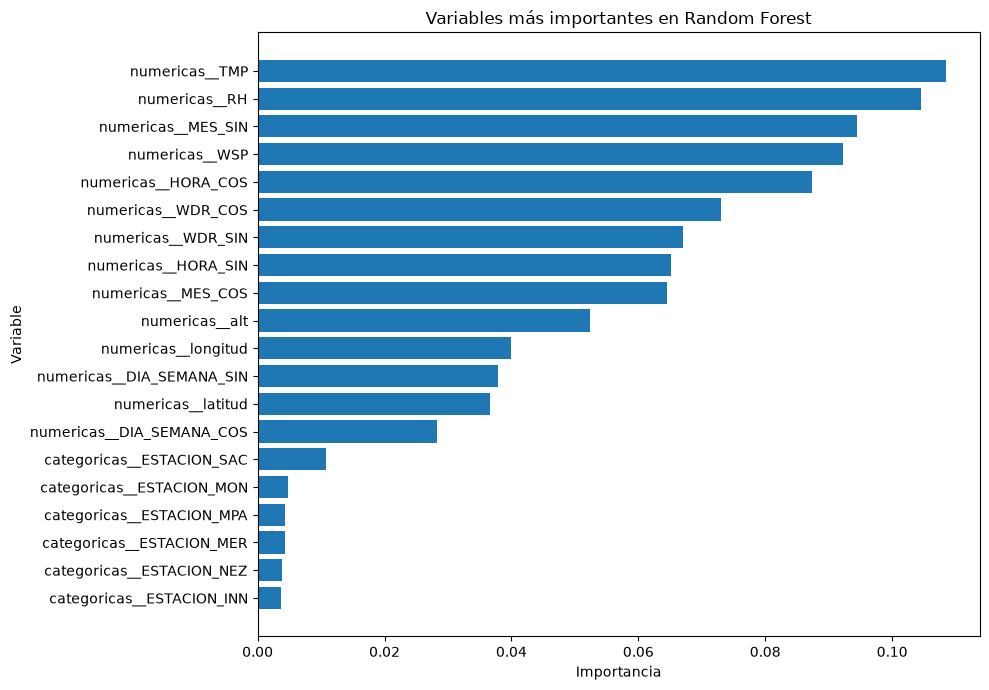

In [54]:
top_importancias = (
    tabla_importancias
    .head(20)
    .sort_values(
        by="importancia",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importancias["variable"],
    top_importancias["importancia"]
)

plt.title(
    "Variables más importantes en Random Forest"
)
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()

plt.savefig(
    CARPETA_FIGURAS
    / "importancia_variables_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [55]:
ruta_predicciones = (
    CARPETA_RESULTADOS
    / "predicciones_pm25_2025.csv"
)

resultados_prueba.to_csv(
    ruta_predicciones,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Predicciones guardadas:",
    ruta_predicciones.exists()
)

Predicciones guardadas: True


In [56]:
error_por_estacion.to_csv(
    CARPETA_TABLAS
    / "error_modelo_por_estacion.csv",
    index=False,
    encoding="utf-8-sig"
)

In [57]:
tabla_importancias.to_csv(
    CARPETA_TABLAS
    / "importancia_variables_random_forest.csv",
    index=False,
    encoding="utf-8-sig"
)

In [58]:
joblib.dump(
    modelo_dummy,
    CARPETA_MODELOS
    / "dummy_regressor.joblib"
)

['..\\resultados\\modelos\\dummy_regressor.joblib']

In [59]:
joblib.dump(
    modelo_lineal,
    CARPETA_MODELOS
    / "regresion_lineal_pm25.joblib"
)

['..\\resultados\\modelos\\regresion_lineal_pm25.joblib']

In [60]:
joblib.dump(
    modelo_rf,
    CARPETA_MODELOS
    / "random_forest_pm25.joblib"
)

print("Modelos guardados correctamente")

Modelos guardados correctamente


In [61]:
for archivo in sorted(
    CARPETA_MODELOS.glob("*.joblib")
):
    print(archivo.name)

dummy_regressor.joblib
random_forest_pm25.joblib
regresion_lineal_pm25.joblib


## 10. Evaluación exploratoria de episodios elevados

De manera preliminar, se utilizará el percentil 90 de PM2.5 del conjunto de entrenamiento como umbral estadístico de concentración elevada.

Este umbral no sustituye criterios normativos ni de salud pública y deberá validarse con el asesor.

In [62]:
umbral_p90 = y_train.quantile(0.90)

print(
    "Percentil 90 de PM2.5 en entrenamiento:",
    round(umbral_p90, 2)
)

Percentil 90 de PM2.5 en entrenamiento: 38.0


In [63]:
resultados_prueba[
    "ELEVADO_REAL"
] = (
    resultados_prueba["PM25"]
    >= umbral_p90
)

resultados_prueba[
    "ELEVADO_PRED_RF"
] = (
    resultados_prueba["PRED_RF"]
    >= umbral_p90
)

In [ ]:
tabla_episodios = pd.crosstab(
    resultados_prueba[
        "ELEVADO_REAL"
    ],
    resultados_prueba[
        "ELEVADO_PRED_RF"
    ],
    rownames=["Real"],
    colnames=["Predicho"]
)

tabla_episodios

Predicho,False,True
Real,,
False,55512,335
True,3943,348


: 

# Conclusiones del modelado experimental

Se desarrollaron tres modelos de regresión para estimar concentraciones de PM2.5: Dummy Regressor, regresión lineal y Random Forest Regressor.

La evaluación se realizó mediante una separación temporal, utilizando 2024 para entrenamiento y 2025 para prueba. Esta estrategia permitió evaluar la capacidad de los modelos para generalizar a un periodo posterior.

El Dummy Regressor funcionó como referencia mínima, mientras que la regresión lineal permitió evaluar la existencia de relaciones lineales entre PM2.5 y las variables predictoras. Random Forest fue utilizado para representar relaciones no lineales e interacciones entre condiciones meteorológicas, tiempo, ubicación y estación.

Los modelos fueron comparados mediante MAE, RMSE y R². También se analizaron los errores por estación, la relación entre valores reales y predichos, y la importancia de las variables utilizadas por Random Forest.

Finalmente, se realizó una evaluación exploratoria de episodios elevados utilizando el percentil 90 del conjunto de entrenamiento. Este criterio es únicamente estadístico y deberá sustituirse o complementarse con un criterio ambiental validado.

Los resultados servirán como base para ajustar hiperparámetros, evaluar otros algoritmos y desarrollar posteriormente mapas y prototipos de identificación de zonas críticas.